# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Benchmark Model Training Loop


In [11]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))

from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data.pkl")
model_data

ModelData(n_total=921, n_train=500, n_obs=64887)

In [12]:
# Random Seed für Reproduzierbarkeit
SEED = 42
np.random.seed(SEED)

In [13]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating Statistiken
rating_features = [
    "VAR",
    "MEAN",
    # "ENTR",
    # "COUNT",
    "ONE_STAR",
    "TWO_STAR",
    # "THREE_STAR",
    # "FOUR_STAR",
    # "FIVE_STAR",
    # "l_COUNT",
]

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")

# Train/Test Split basierend auf train_indices
train_indices = model_data.train_indices

# Eval und Calibration Indizes (beziehen sich auf den gesamten Datensatz)
eval_indices = model_data.eval_indices
calibration_indices = model_data.calibration_indices

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Eval samples: {len(eval_indices)}")
print(f"  Calibration samples: {len(calibration_indices)}")
print(f"  Total: {len(train_indices) + len(eval_indices) + len(calibration_indices)}")

Business features: 10 Variablen
Rating features: 4 Variablen
Gesamt: 14 Variablen

Train/Test Split:
  Training samples: 500
  Eval samples: 321
  Calibration samples: 100
  Total: 921


## Data Preprocessing (Unified Approach)


In [14]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Target Variable vorbereiten (für alle Daten)
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values
y_train = y[train_indices]

# ============================================================================
# Unified Preprocessing: Ein Imputer + Scaler für alle Features
# ============================================================================
all_features = business_features + rating_features
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# One-Hot Encoding (nur einmal!)
df_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Imputer und Scaler auf Train-Daten fitten
numeric_train = df_encoded.iloc[train_indices][numeric_cols]
imputer.fit(numeric_train)
scaler.fit(imputer.transform(numeric_train))

# Imputing und Scaling auf alle Daten anwenden
numeric_data_imputed = imputer.transform(df_encoded[numeric_cols])
numeric_data = scaler.transform(numeric_data_imputed)

# Erstelle finalen DataFrame mit allen Features
df_preprocessed = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_encoded.index
)
dummy_cols = [col for col in df_encoded.columns if col not in numeric_cols]
df_preprocessed = pd.concat([df_preprocessed, df_encoded[dummy_cols]], axis=1)


# ============================================================================
# Feature Sets: Wähle passende Spalten aus dem preprocessed DataFrame
# ============================================================================
# 1. X_mean: Nur Mean Rating (braucht kein Preprocessing)
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# 2. X_business: Business Covariates (aus preprocessed DataFrame)
business_cols_numeric = [
    col for col in business_features if col not in categorical_cols
]
business_cols_dummy = [
    col for col in df_preprocessed.columns if col.startswith("category_")
]
business_cols = business_cols_numeric + business_cols_dummy
X_business = df_preprocessed[business_cols]

# 3. X_all: Alle Features (gesamter preprocessed DataFrame)
X_all = df_preprocessed

# Train Splits
X_mean_train = X_mean[train_indices]
X_business_train = X_business.iloc[train_indices]
X_all_train = X_all.iloc[train_indices]

# ============================================================================
# Zusammenfassung
# ============================================================================
print()
print("DATENVORBEREITUNGEN ABGESCHLOSSEN")
print("=" * 80)
print(f"\nTarget Variable (y):")
print(f"  Total samples: {len(y)} (Closed: {sum(y)}, Open: {len(y) - sum(y)})")
print(
    f"  Train samples: {len(y_train)} (Closed: {sum(y_train)}, Open: {len(y_train) - sum(y_train)})"
)

print(f"\nFeature Sets:")
print(f"  X_mean:     {X_mean.shape} (Train: {X_mean_train.shape})")
print(f"  X_business: {X_business.shape} (Train: {X_business_train.shape})")
print(f"  X_all:      {X_all.shape} (Train: {X_all_train.shape})")

print(f"\nFeature Details:")
print(f"  Mean Rating: 1 Variable")
print(
    f"  Business Covariates: {len(X_business.columns)} Variablen (nach One-Hot Encoding)"
)
print(f"  All Features: {len(X_all.columns)} Variablen (nach One-Hot Encoding)")


DATENVORBEREITUNGEN ABGESCHLOSSEN

Target Variable (y):
  Total samples: 921 (Closed: 225, Open: 696)
  Train samples: 500 (Closed: 127, Open: 373)

Feature Sets:
  X_mean:     (921, 1) (Train: (500, 1))
  X_business: (921, 17) (Train: (500, 17))
  X_all:      (921, 21) (Train: (500, 21))

Feature Details:
  Mean Rating: 1 Variable
  Business Covariates: 17 Variablen (nach One-Hot Encoding)
  All Features: 21 Variablen (nach One-Hot Encoding)


## Training alle Benchmark-Modelle in einer Schleife


In [15]:
# ============================================================================
# Feature Sets
# ============================================================================
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from helpers import get_model_performance


feature_sets = {
    "Mean Rating": (X_mean, X_mean_train),
    "Business Cov.": (X_business, X_business_train),
    "All Features": (X_all, X_all_train),
}

# ============================================================================
# Training Loop: Trainiere alle Modelle für jedes Feature Set
# ============================================================================
results = {}
performance_data = []

print("=" * 80)
print("TRAINING BENCHMARK MODELS")
print("=" * 80)

for feature_name, (X, X_train) in feature_sets.items():
    print(f"\n{feature_name}:")

    # ========================================================================
    # 1. Logistic Regression
    # ========================================================================
    print(f"  - Training Logistic Regression...", end=" ")
    lr = LogisticRegressionCV(
        random_state=SEED, max_iter=1000, cv=5, Cs=[0.01, 0.1, 1, 10]
    )
    lr.fit(X_train, y_train)
    y_proba_lr = lr.predict_proba(X)[:, 1]

    train_auc_lr = 100 * roc_auc_score(y_train, y_proba_lr[train_indices])
    perf_lr = get_model_performance(
        y_prob=y_proba_lr,
        y_exp=y,
        calibration_indices=calibration_indices,
        eval_indices=eval_indices,
    )

    results[("Logistic Regression", feature_name)] = {
        "model": lr,
        "y_proba": y_proba_lr,
        "train_auc": train_auc_lr,
        "performance": perf_lr,
    }

    performance_data.append(
        {
            "Model Type": "Logistic Regression",
            "Features": feature_name,
            "In-Sample AUC": round(train_auc_lr, 2),
            "Out-of-Sample AUC": perf_lr["auc"],
            "Balanced Accuracy": perf_lr["balanced_accuracy"],
            "F1 Score": perf_lr["f1"],
            "Specificity": perf_lr["specificity"],
            "Sensitivity": perf_lr["sensitivity"],
            "Threshold": perf_lr["threshold"],
        }
    )

    print(f"✓ (OOS AUC: {perf_lr['auc']:.2f}%)")

    # ========================================================================
    # 2. Random Forest
    # ========================================================================
    print(f"  - Training Random Forest...", end=" ")
    rf = RandomForestClassifier(
        random_state=SEED,
        n_estimators=500,
        max_leaf_nodes=5,
        min_samples_leaf=10,
        max_features="sqrt",
    )
    rf.fit(X_train, y_train)
    y_proba_rf = rf.predict_proba(X)[:, 1]

    train_auc_rf = 100 * roc_auc_score(y_train, y_proba_rf[train_indices])
    perf_rf = get_model_performance(
        y_prob=y_proba_rf,
        y_exp=y,
        calibration_indices=calibration_indices,
        eval_indices=eval_indices,
    )

    results[("Random Forest", feature_name)] = {
        "model": rf,
        "y_proba": y_proba_rf,
        "train_auc": train_auc_rf,
        "performance": perf_rf,
    }

    performance_data.append(
        {
            "Model Type": "Random Forest",
            "Features": feature_name,
            "In-Sample AUC": round(train_auc_rf, 2),
            "Out-of-Sample AUC": perf_rf["auc"],
            "Balanced Accuracy": perf_rf["balanced_accuracy"],
            "F1 Score": perf_rf["f1"],
            "Specificity": perf_rf["specificity"],
            "Sensitivity": perf_rf["sensitivity"],
            "Threshold": perf_rf["threshold"],
        }
    )

    print(f"✓ (OOS AUC: {perf_rf['auc']:.2f}%)")

    # ========================================================================
    # 3. XGBoost
    # ========================================================================
    print(f"  - Training XGBoost...", end=" ")
    xgb = XGBClassifier(
        random_state=SEED,
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        eval_metric="auc",
    )
    xgb.fit(X_train, y_train)
    y_proba_xgb = xgb.predict_proba(X)[:, 1]

    train_auc_xgb = 100 * roc_auc_score(y_train, y_proba_xgb[train_indices])
    perf_xgb = get_model_performance(
        y_prob=y_proba_xgb,
        y_exp=y,
        calibration_indices=calibration_indices,
        eval_indices=eval_indices,
    )

    results[("XGBoost", feature_name)] = {
        "model": xgb,
        "y_proba": y_proba_xgb,
        "train_auc": train_auc_xgb,
        "performance": perf_xgb,
    }

    performance_data.append(
        {
            "Model Type": "XGBoost",
            "Features": feature_name,
            "In-Sample AUC": round(train_auc_xgb, 2),
            "Out-of-Sample AUC": perf_xgb["auc"],
            "Balanced Accuracy": perf_xgb["balanced_accuracy"],
            "F1 Score": perf_xgb["f1"],
            "Specificity": perf_xgb["specificity"],
            "Sensitivity": perf_xgb["sensitivity"],
            "Threshold": perf_xgb["threshold"],
        }
    )

    print(f"✓ (OOS AUC: {perf_xgb['auc']:.2f}%)")

print("\n" + "=" * 80)
print(f"TRAINING ABGESCHLOSSEN: {len(results)} Modelle trainiert")
print("=" * 80)

TRAINING BENCHMARK MODELS

Mean Rating:
  - Training Logistic Regression... ✓ (OOS AUC: 48.78%)
  - Training Random Forest... ✓ (OOS AUC: 52.51%)
  - Training XGBoost... ✓ (OOS AUC: 51.63%)

Business Cov.:
  - Training Logistic Regression... ✓ (OOS AUC: 70.28%)
  - Training Random Forest... ✓ (OOS AUC: 77.38%)
  - Training XGBoost... ✓ (OOS AUC: 77.82%)

All Features:
  - Training Logistic Regression... ✓ (OOS AUC: 76.35%)
  - Training Random Forest... ✓ (OOS AUC: 76.56%)
  - Training XGBoost... ✓ (OOS AUC: 78.28%)

TRAINING ABGESCHLOSSEN: 9 Modelle trainiert


# Comprehensive Performance Metrics

---

## Detaillierte Performance-Metriken für alle Modelle

Umfassende Auswertung mit:

- AUC
- Balanced Accuracy
- F1 Score
- Specificity
- Sensitivity
- Optimal Threshold


In [16]:
import pandas as pd

# DataFrame erstellen aus performance_data (wurde in der Training Loop erstellt)
comprehensive_performance = pd.DataFrame(performance_data)

# Nach Out-of-Sample AUC sortieren
comprehensive_performance_sorted = comprehensive_performance.sort_values(
    "Out-of-Sample AUC", ascending=False
)

print("=" * 130)
print("COMPREHENSIVE MODEL PERFORMANCE METRICS")
print("=" * 130)
print(comprehensive_performance_sorted.to_string(index=False))

# Bestes Modell identifizieren
best_model = comprehensive_performance_sorted.iloc[0]
print("\n" + "=" * 130)
print("BEST MODEL OVERALL (by Out-of-Sample AUC)")
print("=" * 130)
print(f"\nModel: {best_model['Model Type']} - {best_model['Features']}")
print(f"  In-Sample AUC: {best_model['In-Sample AUC']}")
print(f"  Out-of-Sample AUC: {best_model['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_model['Balanced Accuracy']}")
print(f"  F1 Score: {best_model['F1 Score']}")
print(f"  Specificity: {best_model['Specificity']}")
print(f"  Sensitivity: {best_model['Sensitivity']}")
print(f"  Optimal Threshold: {best_model['Threshold']}")

COMPREHENSIVE MODEL PERFORMANCE METRICS
         Model Type      Features  In-Sample AUC  Out-of-Sample AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
            XGBoost  All Features          93.92              78.28              71.19     50.67        60.96        81.43     0.2281
            XGBoost Business Cov.          92.10              77.82              68.38     48.31        65.34        71.43     0.2620
      Random Forest Business Cov.          87.32              77.38              69.18     49.26        66.93        71.43     0.2697
      Random Forest  All Features          90.21              76.56              70.05     49.77        62.95        77.14     0.2649
Logistic Regression  All Features          85.24              76.35              68.96     50.00        76.49        61.43     0.3070
Logistic Regression Business Cov.          75.56              70.28              63.75     43.39        68.92        58.57     0.2892
      Random Forest   

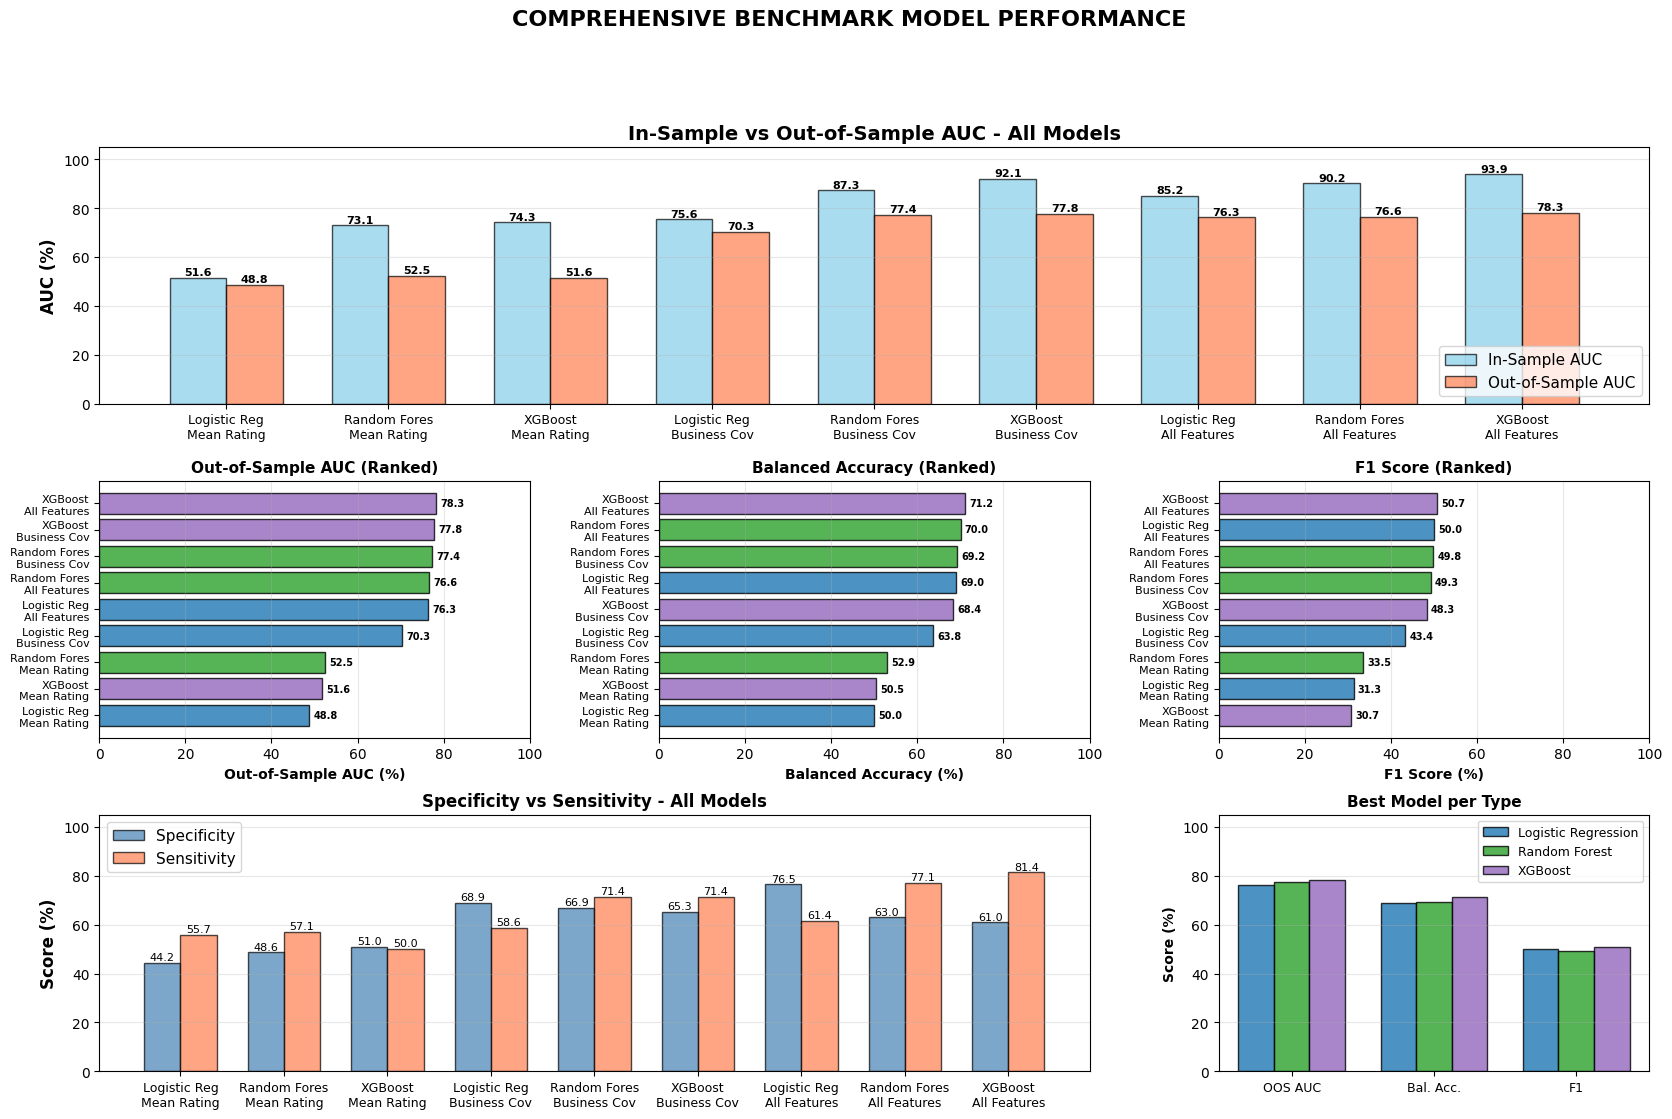

In [17]:
import matplotlib.pyplot as plt

# Comprehensive Visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Farben für verschiedene Modelltypen
colors_map = {
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#2ca02c",
    "XGBoost": "#9467bd",
}

# Modell-Labels für die Plots
model_labels = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in comprehensive_performance.iterrows()
]
colors = [colors_map[mt] for mt in comprehensive_performance["Model Type"]]

# 1. In-Sample vs Out-of-Sample AUC (großer Plot oben)
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(model_labels))
width = 0.35

ax1.bar(
    x_pos - width / 2,
    comprehensive_performance["In-Sample AUC"].values,
    width,
    label="In-Sample AUC",
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
)
ax1.bar(
    x_pos + width / 2,
    comprehensive_performance["Out-of-Sample AUC"].values,
    width,
    label="Out-of-Sample AUC",
    alpha=0.7,
    color="coral",
    edgecolor="black",
)

ax1.set_ylabel("AUC (%)", fontsize=12, fontweight="bold")
ax1.set_title(
    "In-Sample vs Out-of-Sample AUC - All Models", fontsize=14, fontweight="bold"
)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(model_labels, fontsize=9, rotation=0)
ax1.set_ylim([0, 105])
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (in_val, out_val) in enumerate(
    zip(
        comprehensive_performance["In-Sample AUC"].values,
        comprehensive_performance["Out-of-Sample AUC"].values,
    )
):
    ax1.text(
        i - width / 2,
        in_val + 1,
        f"{in_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )
    ax1.text(
        i + width / 2,
        out_val + 1,
        f"{out_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

# 2. Out-of-Sample AUC (sortiert)
ax2 = fig.add_subplot(gs[1, 0])
sorted_labels = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in comprehensive_performance_sorted.iterrows()
]
sorted_colors = [
    colors_map[mt] for mt in comprehensive_performance_sorted["Model Type"]
]

ax2.barh(
    range(len(sorted_labels)),
    comprehensive_performance_sorted["Out-of-Sample AUC"].values,
    color=sorted_colors,
    alpha=0.8,
    edgecolor="black",
)
ax2.set_yticks(range(len(sorted_labels)))
ax2.set_yticklabels(sorted_labels, fontsize=8)
ax2.set_xlabel("Out-of-Sample AUC (%)", fontsize=10, fontweight="bold")
ax2.set_title("Out-of-Sample AUC (Ranked)", fontsize=11, fontweight="bold")
ax2.set_xlim([0, 100])
ax2.grid(axis="x", alpha=0.3)
ax2.invert_yaxis()
for i, v in enumerate(comprehensive_performance_sorted["Out-of-Sample AUC"].values):
    ax2.text(v + 1, i, f"{v:.1f}", va="center", fontsize=7, fontweight="bold")

# 3. Balanced Accuracy
ax3 = fig.add_subplot(gs[1, 1])
sorted_by_bal = comprehensive_performance.sort_values(
    "Balanced Accuracy", ascending=False
)
sorted_labels_bal = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in sorted_by_bal.iterrows()
]
sorted_colors_bal = [colors_map[mt] for mt in sorted_by_bal["Model Type"]]

ax3.barh(
    range(len(sorted_labels_bal)),
    sorted_by_bal["Balanced Accuracy"].values,
    color=sorted_colors_bal,
    alpha=0.8,
    edgecolor="black",
)
ax3.set_yticks(range(len(sorted_labels_bal)))
ax3.set_yticklabels(sorted_labels_bal, fontsize=8)
ax3.set_xlabel("Balanced Accuracy (%)", fontsize=10, fontweight="bold")
ax3.set_title("Balanced Accuracy (Ranked)", fontsize=11, fontweight="bold")
ax3.set_xlim([0, 100])
ax3.grid(axis="x", alpha=0.3)
ax3.invert_yaxis()
for i, v in enumerate(sorted_by_bal["Balanced Accuracy"].values):
    ax3.text(v + 1, i, f"{v:.1f}", va="center", fontsize=7, fontweight="bold")

# 4. F1 Score
ax4 = fig.add_subplot(gs[1, 2])
sorted_by_f1 = comprehensive_performance.sort_values("F1 Score", ascending=False)
sorted_labels_f1 = [
    f"{row['Model Type'][:12]}\n{row['Features'][:12]}"
    for _, row in sorted_by_f1.iterrows()
]
sorted_colors_f1 = [colors_map[mt] for mt in sorted_by_f1["Model Type"]]

ax4.barh(
    range(len(sorted_labels_f1)),
    sorted_by_f1["F1 Score"].values,
    color=sorted_colors_f1,
    alpha=0.8,
    edgecolor="black",
)
ax4.set_yticks(range(len(sorted_labels_f1)))
ax4.set_yticklabels(sorted_labels_f1, fontsize=8)
ax4.set_xlabel("F1 Score (%)", fontsize=10, fontweight="bold")
ax4.set_title("F1 Score (Ranked)", fontsize=11, fontweight="bold")
ax4.set_xlim([0, 100])
ax4.grid(axis="x", alpha=0.3)
ax4.invert_yaxis()
for i, v in enumerate(sorted_by_f1["F1 Score"].values):
    ax4.text(v + 1, i, f"{v:.1f}", va="center", fontsize=7, fontweight="bold")

# 5. Specificity vs Sensitivity (grouped)
ax5 = fig.add_subplot(gs[2, :2])
x_pos = np.arange(len(model_labels))
width = 0.35

ax5.bar(
    x_pos - width / 2,
    comprehensive_performance["Specificity"].values,
    width,
    label="Specificity",
    alpha=0.7,
    color="steelblue",
    edgecolor="black",
)
ax5.bar(
    x_pos + width / 2,
    comprehensive_performance["Sensitivity"].values,
    width,
    label="Sensitivity",
    alpha=0.7,
    color="coral",
    edgecolor="black",
)

ax5.set_ylabel("Score (%)", fontsize=12, fontweight="bold")
ax5.set_title("Specificity vs Sensitivity - All Models", fontsize=12, fontweight="bold")
ax5.set_xticks(x_pos)
ax5.set_xticklabels(model_labels, fontsize=9, rotation=0)
ax5.set_ylim([0, 105])
ax5.legend(fontsize=11)
ax5.grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (spec, sens) in enumerate(
    zip(
        comprehensive_performance["Specificity"].values,
        comprehensive_performance["Sensitivity"].values,
    )
):
    ax5.text(i - width / 2, spec + 1, f"{spec:.1f}", ha="center", fontsize=8)
    ax5.text(i + width / 2, sens + 1, f"{sens:.1f}", ha="center", fontsize=8)

# 6. Model Type Comparison (Best of Each Type)
ax6 = fig.add_subplot(gs[2, 2])
best_per_type = comprehensive_performance.loc[
    comprehensive_performance.groupby("Model Type")["Out-of-Sample AUC"].idxmax()
]

metrics_to_compare = ["Out-of-Sample AUC", "Balanced Accuracy", "F1 Score"]
x_labels = ["OOS AUC", "Bal. Acc.", "F1"]
x_pos = np.arange(len(metrics_to_compare))
width = 0.25

for i, (idx, model) in enumerate(best_per_type.iterrows()):
    values = [model[m] for m in metrics_to_compare]
    ax6.bar(
        x_pos + i * width,
        values,
        width,
        label=model["Model Type"],
        alpha=0.8,
        color=colors_map[model["Model Type"]],
        edgecolor="black",
    )

ax6.set_ylabel("Score (%)", fontsize=10, fontweight="bold")
ax6.set_title("Best Model per Type", fontsize=11, fontweight="bold")
ax6.set_xticks(x_pos + width)
ax6.set_xticklabels(x_labels, fontsize=9)
ax6.set_ylim([0, 105])
ax6.legend(fontsize=9)
ax6.grid(axis="y", alpha=0.3)

plt.suptitle(
    "COMPREHENSIVE BENCHMARK MODEL PERFORMANCE", fontsize=16, fontweight="bold", y=0.995
)

plt.show()

# Comparison with HMM Models

---

## Integration der HMM-Modelle (aus 3-analysis)

Wir laden die trainierten HMM und VDHMM Modelle (seed=42) und vergleichen sie mit den Benchmark-Modellen.


In [18]:
from helpers import Model
from constants import FITTED_MODEL_FOLDER

# Lade HMM und VDHMM Modelle (nur seed=42, da die anderen kein log_lik_test haben)
hmm_models = []

for model_name in ["hmm", "vdhmm"]:
    for S in [2, 3, 4]:
        try:
            model_path = FITTED_MODEL_FOLDER / f"{model_name}_{S}_seed42_cmdstan.pkl"
            model = Model.from_pickle(model_path)

            # # Berechne AUC für Trainingsdaten (in Prozent)
            y_true = np.array(model.stan_data["Closed"])
            # results_df.loc[k, "AUC_TRAIN"] = 100 * roc_auc_score(
            #     y_true_train, close_prob_mean[:500]
            # )

            # y_true_test = np.array(model.stan_data["Closed"][500:])
            # # Annahme: Die Schrittweite passt, ggf. muss die Dimensionalität geprüft werden!
            # close_prob_test_mean = np.mean(model.fit.stan_variable("close_prob"), axis=0)
            # results_df.loc[k, "AUC_TEST"] = 100 * roc_auc_score(
            #     y_true_test, close_prob_test_mean[500:]
            # )

            # Extrahiere close_prob für alle Daten
            close_prob = model.fit.stan_variable("close_prob")
            close_prob_mean = close_prob.mean(axis=0)

            # Berechne In-Sample und Out-of-Sample AUC
            train_auc = 100 * roc_auc_score(
                y_true[train_indices], close_prob_mean[train_indices]
            )

            # Performance auf Eval-Daten mit get_model_performance
            perf_dict = get_model_performance(
                y_prob=close_prob_mean,
                y_exp=y_true,
                calibration_indices=calibration_indices,
                eval_indices=eval_indices,
            )

            hmm_models.append(
                {
                    "Model Type": model_name.upper(),
                    "Features": f"{S} States",
                    "In-Sample AUC": round(train_auc, 2),
                    "Out-of-Sample AUC": perf_dict["auc"],
                    "Balanced Accuracy": perf_dict["balanced_accuracy"],
                    "F1 Score": perf_dict["f1"],
                    "Specificity": perf_dict["specificity"],
                    "Sensitivity": perf_dict["sensitivity"],
                    "Threshold": perf_dict["threshold"],
                }
            )

            print(f"✓ Loaded {model_name.upper()} with {S} states")

        except Exception as e:
            print(f"✗ Error loading {model_name} with {S} states: {e}")

# Konvertiere zu DataFrame
hmm_performance = pd.DataFrame(hmm_models)
print("\n" + "=" * 80)
print("HMM MODEL PERFORMANCE")
print("=" * 80)
print(hmm_performance.to_string(index=False))

✓ Loaded HMM with 2 states
✓ Loaded HMM with 3 states
✓ Loaded HMM with 4 states
✓ Loaded VDHMM with 2 states
✓ Loaded VDHMM with 3 states
✓ Loaded VDHMM with 4 states

HMM MODEL PERFORMANCE
Model Type Features  In-Sample AUC  Out-of-Sample AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
       HMM 2 States          79.86              78.44              67.70     51.22        82.23        53.16     0.3793
       HMM 3 States          83.83              81.34              72.74     58.54        84.71        60.76     0.4201
       HMM 4 States          83.60              80.78              67.43     51.03        88.02        46.84     0.4575
     VDHMM 2 States          79.26              78.32              69.74     53.08        68.60        70.89     0.2949
     VDHMM 3 States          85.36              83.27              75.69     62.35        84.30        67.09     0.3669
     VDHMM 4 States          85.78              83.72              76.96     63.95       

## Combined Performance Comparison: Benchmark vs HMM Models


In [19]:
# Kombiniere alle Modelle in einem DataFrame
all_models_performance = pd.concat(
    [comprehensive_performance, hmm_performance], ignore_index=True
)

# Sortiere nach Out-of-Sample AUC
all_models_sorted = all_models_performance.sort_values(
    "Out-of-Sample AUC", ascending=False
)

print("=" * 130)
print("ALL MODELS PERFORMANCE COMPARISON (Benchmark + HMM)")
print("=" * 130)
print(all_models_sorted.to_string(index=False))

# Identifiziere das beste Modell insgesamt
best_overall = all_models_sorted.iloc[0]
print("\n" + "=" * 130)
print("BEST MODEL OVERALL (including HMM)")
print("=" * 130)
print(f"\nModel: {best_overall['Model Type']} - {best_overall['Features']}")
print(f"  In-Sample AUC: {best_overall['In-Sample AUC']}")
print(f"  Out-of-Sample AUC: {best_overall['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_overall['Balanced Accuracy']}")
print(f"  F1 Score: {best_overall['F1 Score']}")
print(f"  Specificity: {best_overall['Specificity']}")
print(f"  Sensitivity: {best_overall['Sensitivity']}")
print(f"  Optimal Threshold: {best_overall['Threshold']}")

# Vergleich: Beste HMM vs. Beste Benchmark
best_hmm = all_models_sorted[
    all_models_sorted["Model Type"].isin(["HMM", "VDHMM"])
].iloc[0]
best_benchmark = all_models_sorted[
    ~all_models_sorted["Model Type"].isin(["HMM", "VDHMM"])
].iloc[0]

print("\n" + "=" * 130)
print("BEST HMM MODEL vs. BEST BENCHMARK MODEL")
print("=" * 130)
print(f"\nBest HMM: {best_hmm['Model Type']} - {best_hmm['Features']}")
print(f"  Out-of-Sample AUC: {best_hmm['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_hmm['Balanced Accuracy']}")
print(f"  F1 Score: {best_hmm['F1 Score']}")

print(
    f"\nBest Benchmark: {best_benchmark['Model Type']} - {best_benchmark['Features']}"
)
print(f"  Out-of-Sample AUC: {best_benchmark['Out-of-Sample AUC']}")
print(f"  Balanced Accuracy: {best_benchmark['Balanced Accuracy']}")
print(f"  F1 Score: {best_benchmark['F1 Score']}")

print(
    f"\nAUC Difference: {best_hmm['Out-of-Sample AUC'] - best_benchmark['Out-of-Sample AUC']:.2f} percentage points"
)

ALL MODELS PERFORMANCE COMPARISON (Benchmark + HMM)
         Model Type      Features  In-Sample AUC  Out-of-Sample AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
              VDHMM      4 States          85.78              83.72              76.96     63.95        84.30        69.62     0.3711
              VDHMM      3 States          85.36              83.27              75.69     62.35        84.30        67.09     0.3669
                HMM      3 States          83.83              81.34              72.74     58.54        84.71        60.76     0.4201
                HMM      4 States          83.60              80.78              67.43     51.03        88.02        46.84     0.4575
                HMM      2 States          79.86              78.44              67.70     51.22        82.23        53.16     0.3793
              VDHMM      2 States          79.26              78.32              69.74     53.08        68.60        70.89     0.2949
          

## Visualisierung: Benchmark vs. HMM Models


/var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/ipykernel_35498/2580730796.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


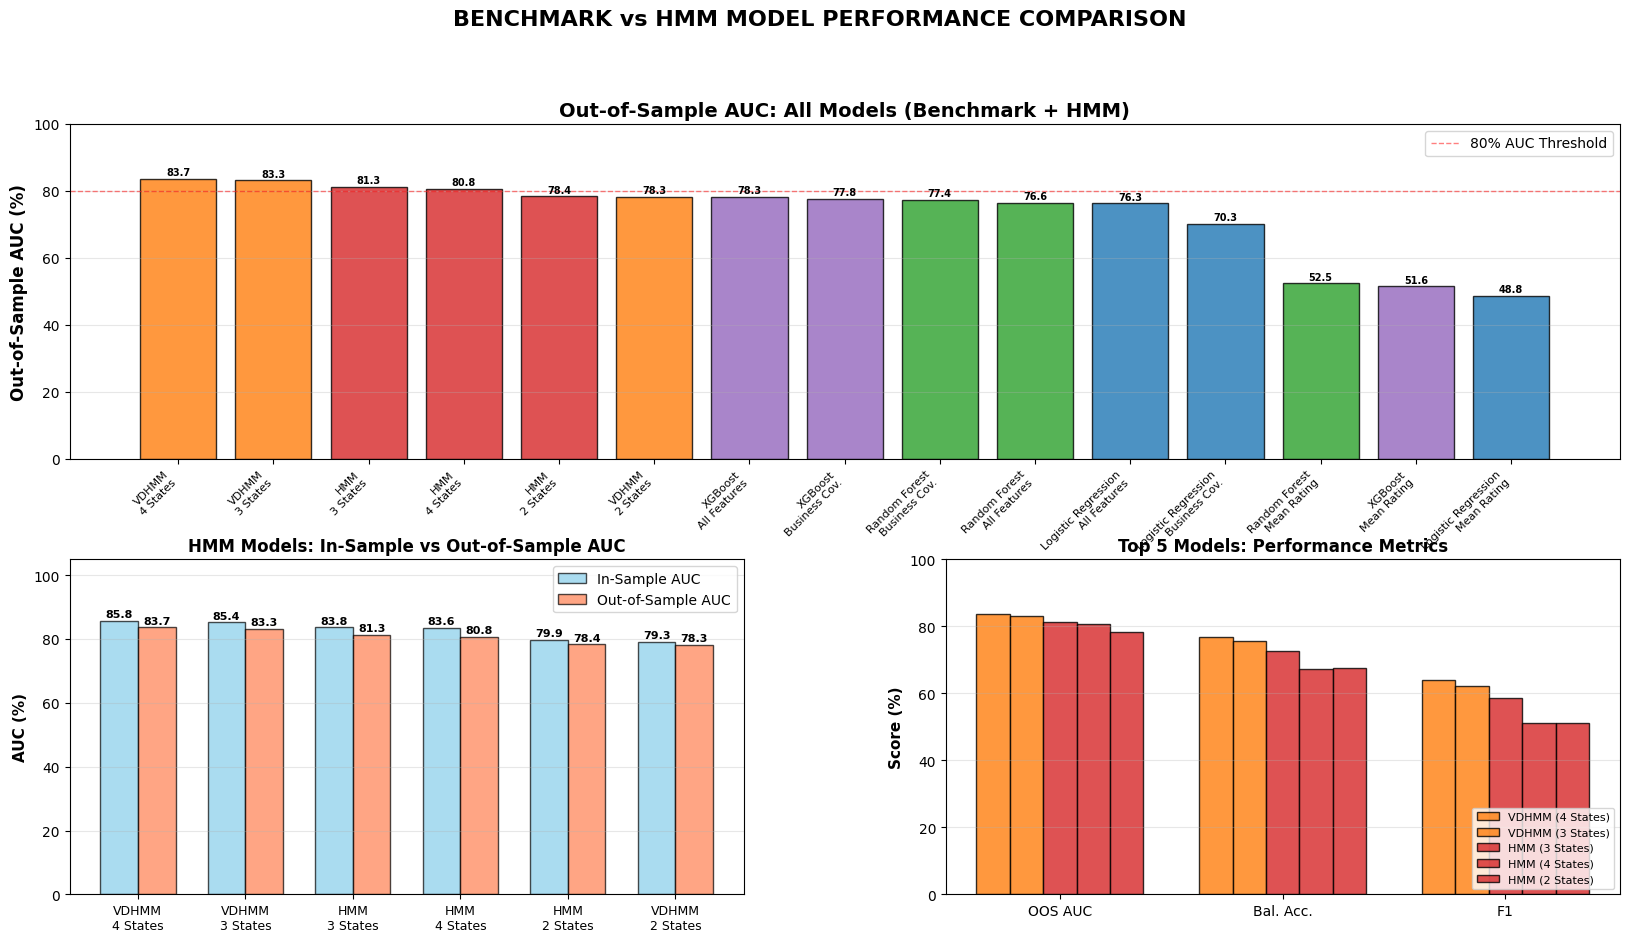

In [20]:
import matplotlib.pyplot as plt

# Erweitere das Farbschema für HMM und VDHMM
colors_map_extended = {
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#2ca02c",
    "XGBoost": "#9467bd",
    "HMM": "#d62728",
    "VDHMM": "#ff7f0e",
}

# Erstelle Visualisierung
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Out-of-Sample AUC Comparison (alle Modelle, sortiert)
ax1 = fig.add_subplot(gs[0, :])
sorted_labels = [
    f"{row['Model Type']}\n{row['Features']}" for _, row in all_models_sorted.iterrows()
]
sorted_colors = [
    colors_map_extended.get(mt, "#888888") for mt in all_models_sorted["Model Type"]
]

x_pos = np.arange(len(sorted_labels))
bars = ax1.bar(
    x_pos,
    all_models_sorted["Out-of-Sample AUC"].values,
    color=sorted_colors,
    alpha=0.8,
    edgecolor="black",
)

ax1.set_ylabel("Out-of-Sample AUC (%)", fontsize=12, fontweight="bold")
ax1.set_title(
    "Out-of-Sample AUC: All Models (Benchmark + HMM)", fontsize=14, fontweight="bold"
)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted_labels, fontsize=8, rotation=45, ha="right")
ax1.set_ylim([0, 100])
ax1.grid(axis="y", alpha=0.3)
ax1.axhline(
    y=80, color="red", linestyle="--", linewidth=1, alpha=0.5, label="80% AUC Threshold"
)
ax1.legend()

# Werte über Balken
for i, v in enumerate(all_models_sorted["Out-of-Sample AUC"].values):
    ax1.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=7, fontweight="bold")

# 2. In-Sample vs Out-of-Sample AUC für HMM Modelle
ax2 = fig.add_subplot(gs[1, 0])
hmm_data = all_models_sorted[all_models_sorted["Model Type"].isin(["HMM", "VDHMM"])]
x_pos = np.arange(len(hmm_data))
width = 0.35

ax2.bar(
    x_pos - width / 2,
    hmm_data["In-Sample AUC"].values,
    width,
    label="In-Sample AUC",
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
)
ax2.bar(
    x_pos + width / 2,
    hmm_data["Out-of-Sample AUC"].values,
    width,
    label="Out-of-Sample AUC",
    alpha=0.7,
    color="coral",
    edgecolor="black",
)

hmm_labels = [
    f"{row['Model Type']}\n{row['Features']}" for _, row in hmm_data.iterrows()
]
ax2.set_ylabel("AUC (%)", fontsize=11, fontweight="bold")
ax2.set_title(
    "HMM Models: In-Sample vs Out-of-Sample AUC", fontsize=12, fontweight="bold"
)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(hmm_labels, fontsize=9)
ax2.set_ylim([0, 105])
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (in_val, out_val) in enumerate(
    zip(hmm_data["In-Sample AUC"].values, hmm_data["Out-of-Sample AUC"].values)
):
    ax2.text(
        i - width / 2,
        in_val + 1,
        f"{in_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )
    ax2.text(
        i + width / 2,
        out_val + 1,
        f"{out_val:.1f}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )

# 3. Vergleich: Top 5 Modelle
ax3 = fig.add_subplot(gs[1, 1])
top5 = all_models_sorted.head(5)
metrics = ["Out-of-Sample AUC", "Balanced Accuracy", "F1 Score"]
x = np.arange(len(metrics))
width = 0.15

for i, (idx, model) in enumerate(top5.iterrows()):
    values = [model[m] for m in metrics]
    label = f"{model['Model Type']} ({model['Features'][:8]})"
    ax3.bar(
        x + i * width,
        values,
        width,
        label=label,
        alpha=0.8,
        color=colors_map_extended.get(model["Model Type"], "#888888"),
        edgecolor="black",
    )

ax3.set_ylabel("Score (%)", fontsize=11, fontweight="bold")
ax3.set_title("Top 5 Models: Performance Metrics", fontsize=12, fontweight="bold")
ax3.set_xticks(x + width * 2)
ax3.set_xticklabels(["OOS AUC", "Bal. Acc.", "F1"], fontsize=10)
ax3.set_ylim([0, 100])
ax3.legend(fontsize=8, loc="lower right")
ax3.grid(axis="y", alpha=0.3)

plt.suptitle(
    "BENCHMARK vs HMM MODEL PERFORMANCE COMPARISON",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout()
plt.show()